# Algorithms for improving the b-chromatic colouring

## Packages

In [56]:
import networkx as nx
import itertools
import matplotlib.pyplot as plt
from b_chromatic_utils import *
from b_chromatic_colouring import get_m_degree, get_dense_vertices
import pandas as pd

## Helpers functions

In [2]:
def is_proper(G, c):
    for u,v in G.edges():
        if((c[u] is not None and c[v] is not None) and (c[u] == c[v])):
            return False
    return True

In [10]:
def get_b_chromatic_vertices(G, c):
    C = set(list(c.values()))
    b_chr_list = []
    for u in G.nodes():
        cNu = {c[v] for v in G.adj[u]}
        if len(cNu) == len(C)-1: b_chr_list.append(u)
    return b_chr_list


## Partition redistribution algorithm (heuristic)

In [83]:
def partition_redistribution(G, f):
    C = set(list(f.values()))
    print("Original set of colours: {}".format(C))
    fp = f.copy()
    Cp = C.copy()
    for c in C:
        Vc = {u for u in G.nodes() if fp[u] == c}
        Vcp = Vc.copy()
        for v in Vc:
            cNv = {fp[u] for u in G.adj[v]}
            if len(cNv) < len(Cp)-1:
                colours_diff = Cp.difference(cNv.union(set([c])))
                assert colours_diff != set()
                cp = list(colours_diff)[0]
                fp[v] = cp
                Vcp.remove(v)
        if Vcp == set():
            Cp.remove(c)
    print("New set of colours: {}".format(Cp))
    return fp

### Testing on a small graph 1

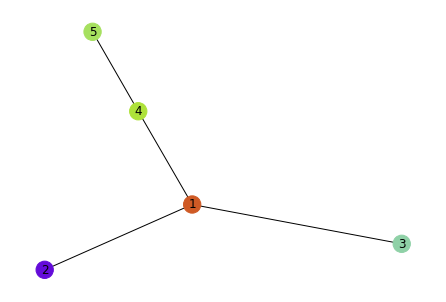

In [4]:
G = nx.Graph()
G.add_edges_from([(1,2), (1,3), (1,4), (4,5)])
f = {}
for i, u in enumerate(G.nodes()):
    f[u] = i+1
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

### Testing on a random graph

Number of colours: 15


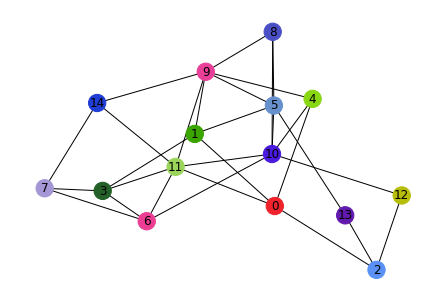

In [48]:
G = nx.random_graphs.gnp_random_graph(15, 0.3)
f = {u:i+1 for i, u in enumerate(G.nodes())}
print("Number of colours: {}".format(len(set(list(f.values())))))
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

In [49]:
fp = partition_redistribution(G, f)
assert is_proper(G, fp)
print("Number of colours: {}".format(len(set(list(fp.values())))))

{12, 13, 14, 15}
Number of colours: 4


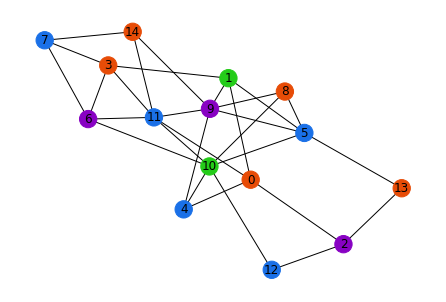

In [55]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fp))

In [51]:
Vp = get_b_chromatic_vertices(G, f)
C = set(f.values())
Vp, C

([0, 1, 3, 4, 5, 6, 8, 9, 10, 11], {12, 13, 14, 15})

We compare the number of colours used and the m-degree of $G$

In [52]:
len(C), get_m_degree(G)

(4, 5)

### Testing on a small graph 2

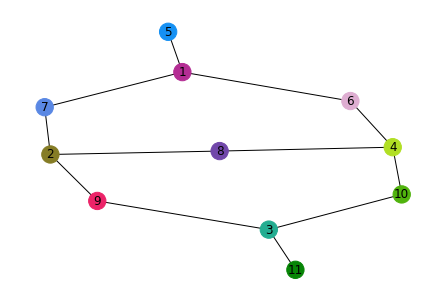

In [81]:
G = nx.Graph()
G.add_edges_from([(1,5), (1,6), (1,7), (2,7), (2,8), (2,9), (3,9), (3,10), (3,11), (4,6), (4,8), (4,10)])
f = {u:u for u in G.nodes()}
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

In [88]:
fp = partition_redistribution(G, f)
assert is_proper(G, fp)
print("Number of colours: {}".format(len(set(list(fp.values())))))
print("m(G) = {}".format(get_m_degree(G)))
print("b-chromatic vertices: {}".format(get_b_chromatic_vertices(G, fp)))
print("Dense vertices: {}".format(get_dense_vertices(G, get_m_degree(G))))

Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
New set of colours: {8, 10, 11}
Number of colours: 3
m(G) = 4
b-chromatic vertices: [1, 6, 7, 2, 8, 9, 3, 4]
Dense vertices: [1, 2, 3, 4]


### Testing on a bunch of random graph with given number of vertices

In [63]:
df_res = {"#colours_used":[], "m_degree_G":[],"#dense_vertices":[],"#b_chromatic_vertices":[]}
for i in range(1000):
    Gi = nx.random_graphs.gnp_random_graph(100, 0.50)
    mi = get_m_degree(Gi)
    Vpi = get_dense_vertices(Gi, mi)
    fi = {u:j+1 for j, u in enumerate(Gi.nodes())}
    fpi = partition_redistribution(Gi, fi)
    assert is_proper(Gi, fpi)
    V_b_chro = get_b_chromatic_vertices(Gi, fpi)
    Ci = set(fpi.values())
    df_res["#colours_used"].append(len(Ci))
    df_res["m_degree_G"].append(mi)
    df_res["#dense_vertices"].append(len(Vpi))
    df_res["#b_chromatic_vertices"].append(len(V_b_chro))

{78, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100}
{77, 79, 81, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
{79, 81, 82, 83, 84, 85, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
{75, 77, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 100}
{77, 79, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
{77, 78, 80, 81, 82, 83, 84, 85, 86, 87, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99, 100}
{79, 80, 81, 82, 83, 84, 85, 86, 87, 89, 90, 91, 92, 93, 94, 95, 97, 98, 99, 100}
{80, 81, 83, 84, 85, 86, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
{77, 78, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 92, 94, 95, 96, 97, 98, 99, 100}
{75, 80, 82, 83, 84, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100}
{77, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
{77, 80, 82, 84, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
{76, 80, 81, 83,

In [64]:
df_res = pd.DataFrame(df_res)

In [65]:
df_res

,#colours_used,m_degree_G,#dense_vertices,#b_chromatic_vertices
0,20,50,57,53
1,20,50,54,63
2,20,51,53,44
3,20,50,60,40
4,21,50,56,35
...,...,...,...,...
995,20,51,63,77
996,20,50,60,66
997,19,50,52,64
998,19,49,50,64
